In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [31]:
df = pd.read_excel("ie_data.xls", index_col=0)

In [32]:
s = df.index.to_series().astype(str)
s = s.str.extract(r'(\d{4})\.(\d{1,2})')  
s = s[0] + '.' + s[1].str.zfill(2)         


df.index = pd.to_datetime(s, format='%Y.%m', errors='coerce')
df = df.dropna()
df = df.sort_index()

In [33]:
data = df[:'1999-12-01'].copy()

In [34]:
data = data.dropna()
data['P'] = pd.to_numeric(data['P'], errors='coerce')
data['logP'] = np.log(data['P'])
data['logD'] = np.log(data['D'])

In [35]:
data['r_t+1'] = np.log(data['P'].shift(-1)+data['D'].shift(-1)) - np.log(data['P'])
data['PDt'] = data['P'] / data['D']
data['delta_d_t+1'] = np.log(data['D'].shift(-1)/data['D'])

In [36]:
data['pd_t'] = np.log(data['PDt'])
data['pd_bar'] = data['pd_t'].mean()
data['rho'] = np.exp(data['pd_bar']) / (1 + np.exp(data['pd_bar']))
data['kappa'] = np.log(1 + np.exp(data['pd_bar'])) - ( data['rho'] * data['pd_bar'] )

In [37]:
data = data.dropna()

In [38]:
data

,P,D,E,CPI,logP,logD,r_t+1,PDt,delta_d_t+1,pd_t,pd_bar,rho,kappa
1985-01-01,171.60,7.573330,16.556700,105.5,5.145166,2.024633,0.123001,22.658461,0.037154,3.120533,3.633423,0.974255,0.119626
1985-01-01,186.20,7.860000,15.023300,108.7,5.226821,2.061787,0.012365,23.689567,-0.031447,3.165035,3.633423,0.974255,0.119626
1985-02-01,180.90,7.616670,16.473300,106,5.197944,2.030339,0.033485,23.750537,0.005673,3.167605,3.633423,0.974255,0.119626
1985-03-01,179.40,7.660000,16.390000,106.4,5.189618,2.036012,0.048348,23.420366,0.003476,3.153606,3.633423,0.974255,0.119626
1985-04-01,180.60,7.686670,16.130000,106.9,5.196285,2.039488,0.064400,23.495220,0.003462,3.156797,3.633423,0.974255,0.119626
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999-06-01,1322.55,16.450000,41.020000,166.2,7.187317,2.800325,0.055126,80.398176,0.003843,4.386991,3.633423,0.974255,0.119626
1999-07-01,1380.99,16.513333,42.000000,166.7,7.230556,2.804168,-0.027101,83.628785,0.003828,4.426388,3.633423,0.974255,0.119626
1999-08-01,1327.49,16.576667,42.980000,167.1,7.191045,2.807996,0.005499,80.081842,0.003813,4.383049,3.633423,0.974255,0.119626
1999-09-01,1318.17,16.640000,43.960000,167.9,7.184000,2.811809,0.065694,79.216947,0.002001,4.372190,3.633423,0.974255,0.119626


In [39]:
import numpy as np
import pandas as pd

# === 基本參數===
delta0 = data['r_t+1'].mean()    
gamma0  = data['delta_d_t+1'].mean()    
delta1 = 0.932     
gamma1 = 0.354     
sigma_mu = 0.016   
sigma_g  = 0.058   
rho_mu_g   = 0.417   

# === 共變數矩陣 ===
cov_mu_g = rho_mu_g * sigma_mu * sigma_g
Sigma = np.array([
    [sigma_mu**2, cov_mu_g],
    [cov_mu_g,      sigma_g**2]
])

# === 模擬樣本期數 ===
T = 179  


mu = np.zeros(T)
g  = np.zeros(T)

# 初始值（以均衡值開）
mu[0] = delta0
g[0]  = gamma0

# === 生成潛在過程 ===
rng = np.random.default_rng(42)
eps = rng.multivariate_normal([0, 0], Sigma, size=T)

for t in range(1, T):
    mu[t] = delta0 + delta1 * (mu[t-1] - delta0) + eps[t,0]
    g[t]  = gamma0  + gamma1 * (g[t-1] - gamma0)  + eps[t,1]

In [40]:
data['mu_t'] = mu
data['g_t']=g

In [41]:
import numpy as np
import pandas as pd

# === 確保時間順序 ===
data = data.sort_values(by=data.columns[0])

# === 建立觀測變數 ===
data["logPD"] = data["logP"] - data["logD"]
Y = data[["delta_d_t+1", "logPD"]].to_numpy()

rho = 0.9743
B1 = 10.870,  B2 = 1.526,  A = 3.297


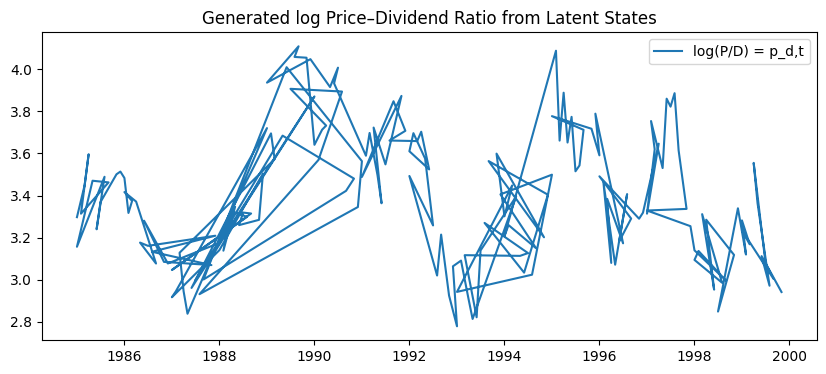

,P,D,E,CPI,logP,logD,r_t+1,PDt,delta_d_t+1,pd_t,pd_bar,rho,kappa,mu_t,g_t,logPD
1985-01-01,171.6,7.57333,16.5567,105.5,5.145166,2.024633,0.123001,22.658461,0.037154,3.297355,3.633423,0.974255,0.119626,0.039149,0.004414,3.120533
1985-03-01,179.4,7.66000,16.3900,106.4,5.189618,2.036012,0.048348,23.420366,0.003476,3.448984,3.633423,0.974255,0.119626,0.021546,-0.021603,3.153606
1985-04-01,180.6,7.68667,16.1300,106.9,5.196285,2.039488,0.064400,23.495220,0.003462,3.596642,3.633423,0.974255,0.119626,0.010397,-0.004270,3.156797
1985-02-01,180.9,7.61667,16.4733,106,5.197944,2.030339,0.033485,23.750537,0.005673,3.313848,3.633423,0.974255,0.119626,0.024150,-0.091589,3.167605
1985-09-01,184.1,7.84000,15.2300,108.3,5.215479,2.059239,0.109383,23.482143,0.005089,3.462635,3.633423,0.974255,0.119626,0.032872,0.067992,3.156240


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd_bar = 3.633423                    
rho = data['rho'].iloc[0]   
k = data['kappa'].iloc[0]

# === 計算 B1, B2, A ===
B1 = 1 / (1 - rho * delta1)
B2 = 1 / (1 - rho * gamma1)
A = ( k + gamma0 - delta0 ) / ( 1 - rho )
print(f"rho = {rho:.4f}")
print(f"B1 = {B1:.3f},  B2 = {B2:.3f},  A = {A:.3f}")

# === 生成 p_d,t ===
pd_t = A - ( B1 * (data["mu_t"] - delta0) ) + ( B2 * (data["g_t"] - gamma0) )
data["pd_t"] = pd_t

# === 可視化 ===
plt.figure(figsize=(10,4))
plt.plot(data["pd_t"], label="log(P/D) = p_d,t")
plt.title("Generated log Price–Dividend Ratio from Latent States")
plt.legend()
plt.show()

data.head()

In [43]:
import numpy as np
import pandas as pd

# --- 既有參數（沿用 Step 2） ---
delta1, gamma1 = 0.932, 0.354
sigma_mu, sigma_g, rho_mu_g = 0.016, 0.058, 0.417
sigma_d = 0.089   # 論文 Table II 的 ε_d 標準差
B1, B2, A = 10.590, 1.487, 3.559
gamma0, delta0 = 0.062, 0.09

# === 狀態轉移矩陣與共變 ===
F = np.array([[delta1, 0],
              [0, gamma1]])

Q = np.array([[sigma_mu**2, rho_mg*sigma_mu*sigma_g],
              [rho_mg*sigma_mu*sigma_g, sigma_g**2]])

# === 觀測矩陣與雜訊 ===
H = np.array([[0, 1],       # Δd_t depends on g_t
              [-B1, B2]])   # p_d,t depends on μ_t, g_t

c = np.array([[g_bar],
              [A]])

R = np.array([[sigma_d**2, 0],
              [0, 1e-6]])   # p_d 無測量誤差 → 給極小值避免奇異

print("F=\n", F)
print("Q=\n", Q)
print("H=\n", H)
print("c=\n", c)
print("R=\n", R)

F=
 [[0.932 0.   ]
 [0.    0.354]]
Q=
 [[0.000256   0.00036766]
 [0.00036766 0.003364  ]]
H=
 [[  0.      1.   ]
 [-10.59    1.487]]
c=
 [[0.062]
 [3.559]]
R=
 [[7.921e-03 0.000e+00]
 [0.000e+00 1.000e-06]]


In [44]:
def kalman_filter(Y, F, H, Q, R, c):
    """
    Y: (T×2) numpy array of [Δd_t, p_d_t]
    returns: filtered states x_{t|t}
    """
    T = len(Y)
    n_state = F.shape[0]
    x_pred = np.zeros((T, n_state, 1))
    P_pred = np.zeros((T, n_state, n_state))
    x_filt = np.zeros((T, n_state, 1))
    P_filt = np.zeros((T, n_state, n_state))
    
    # 初始化
    x_prev = np.zeros((n_state,1))
    P_prev = np.eye(n_state)*1e-4
    
    loglik = 0.0
    for t in range(T):
        # ---- Prediction ----
        x_pred[t] = F @ x_prev
        P_pred[t] = F @ P_prev @ F.T + Q

        # ---- Measurement update ----
        y_pred = (H @ x_pred[t]) + c
        y_err = (Y[t].reshape(-1,1) - y_pred)
        S = H @ P_pred[t] @ H.T + R
        K = P_pred[t] @ H.T @ np.linalg.inv(S)
        
        x_filt[t] = x_pred[t] + K @ y_err
        P_filt[t] = (np.eye(n_state) - K @ H) @ P_pred[t]
        
        # ---- log-likelihood contribution ----
        loglik += -0.5*(np.log(np.linalg.det(S)) + y_err.T @ np.linalg.inv(S) @ y_err)
        
        # next iteration
        x_prev, P_prev = x_filt[t], P_filt[t]

    return x_filt.squeeze(), loglik


In [45]:
# 準備模擬觀測資料
Y = np.column_stack([
    data["g_t"] - gamma0 + np.random.normal(0, sigma_d, size=len(data)),
    data["pd_t"]
])

# 跑 Kalman filter
x_filt, loglik = kalman_filter(Y, F, H, Q, R, c)
print("log-likelihood:", float(loglik))

log-likelihood: 292.7428637929529


C:\Users\open7\AppData\Local\Temp\ipykernel_13536\2048379574.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("log-likelihood:", float(loglik))


In [46]:
import numpy as np
from scipy.optimize import minimize

# ---- 固定常數 ----
delta0, gamma0 = 0.09, 0.062
A, B1, B2 = 3.559, 10.590, 1.487
pd_bar = 3.6
rho = 0.974255
k = 0.119626

# ---- 定義對數似然函數 ----
def neg_loglik(params, Y, A, B1, B2, mu_bar, g_bar):
    delta1, gamma1, sigma_mu, sigma_g, rho_mg, sigma_d = params
    
    # 合理性限制（確保穩定、正變異）
    if not (0 < delta1 < 0.999 and 0 < gamma1 < 0.999 and
            -0.99 < rho_mg < 0.99 and sigma_mu>0 and sigma_g>0 and sigma_d>0):
        return 1e6

    # === matrices ===
    F = np.array([[delta1, 0],
                  [0, gamma1]])
    Q = np.array([[sigma_mu**2, rho_mg*sigma_mu*sigma_g],
                  [rho_mg*sigma_mu*sigma_g, sigma_g**2]])
    H = np.array([[0, 1],
                  [-B1, B2]])
    c = np.array([[g_bar],
                  [A]])
    R = np.array([[sigma_d**2, 0],
                  [0, 1e-6]])

    # === Kalman filter core ===
    n_state = F.shape[0]
    x_prev = np.zeros((n_state,1))
    P_prev = np.eye(n_state)*1e-4
    loglik = 0.0
    for t in range(len(Y)):
        x_pred = F @ x_prev
        P_pred = F @ P_prev @ F.T + Q

        y_pred = H @ x_pred + c
        y_err  = Y[t].reshape(-1,1) - y_pred
        S = H @ P_pred @ H.T + R
        try:
            K = P_pred @ H.T @ np.linalg.inv(S)
        except np.linalg.LinAlgError:
            return 1e6
        
        loglik += -0.5*(np.log(np.linalg.det(S)) + y_err.T @ np.linalg.inv(S) @ y_err)
        
        # 更新
        x_prev = x_pred + K @ y_err
        P_prev = (np.eye(n_state) - K @ H) @ P_pred

    return -float(loglik)   # minimize → 負號

In [47]:
# 初始值（可取 Step 3 的參數作起點）
init_params = [0.93, 0.35, 0.016, 0.058, 0.4, 0.089]

res = minimize(
    neg_loglik,
    init_params,
    args=(Y, A, B1, B2, delta0, gamma0),
    method='L-BFGS-B',
    options={'maxiter': 200, 'disp': True}
)

print("\n=== MLE 結果 ===")
names = ["delta1","gamma1","sigma_mu","sigma_g","rho_mu_g","sigma_d"]
for name, val in zip(names, res.x):
    print(f"{name:10s} = {val:.4f}")
print("LogLik =", -res.fun)

C:\Users\open7\AppData\Local\Temp\ipykernel_13536\2964926563.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return -float(loglik)   # minimize → 負號



=== MLE 結果 ===
delta1     = 0.5533
gamma1     = 0.9976
sigma_mu   = 0.0237
sigma_g    = 0.0104
rho_mu_g   = -0.3870
sigma_d    = 0.1088
LogLik = 453.73080805341493


使用參數：
δ1=0.553, γ1=0.998, σμ=0.024, σg=0.010, ρμg=-0.387, σd=0.109


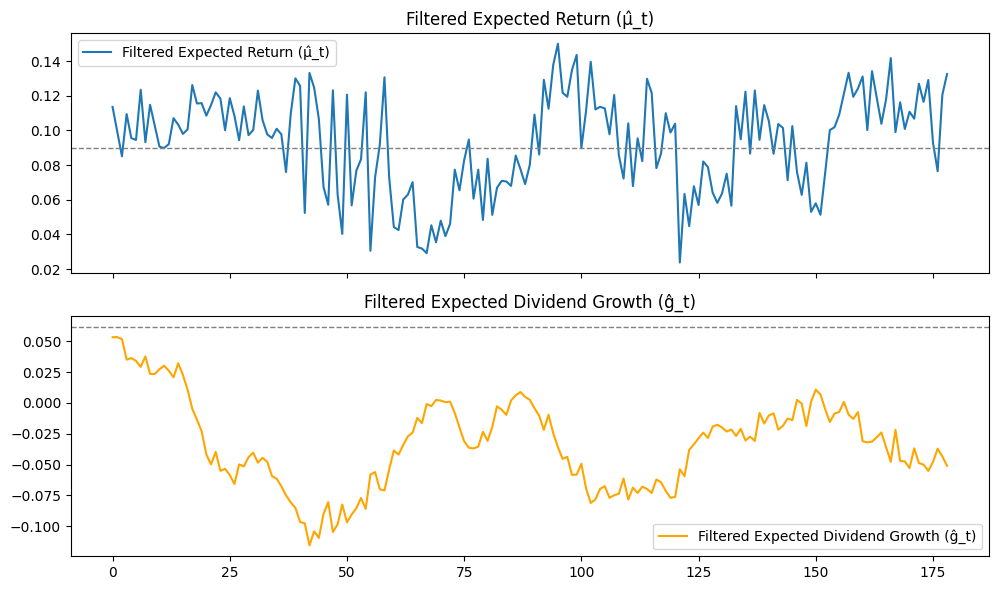

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# === Step 5: 使用 MLE 估計值 ===
delta1, gamma1 = res.x[0], res.x[1]
sigma_mu, sigma_g, rho_mg, sigma_d = res.x[2], res.x[3], res.x[4], res.x[5]

print("使用參數：")
print(f"δ1={delta1:.3f}, γ1={gamma1:.3f}, σμ={sigma_mu:.3f}, σg={sigma_g:.3f}, ρμg={rho_mg:.3f}, σd={sigma_d:.3f}")

# === 建立矩陣 ===
F = np.array([[delta1, 0],
              [0, gamma1]])

Q = np.array([[sigma_mu**2, rho_mg*sigma_mu*sigma_g],
              [rho_mg*sigma_mu*sigma_g, sigma_g**2]])

H = np.array([[0, 1],
              [-B1, B2]])
c = np.array([[g_bar],
              [A]])
R = np.array([[sigma_d**2, 0],
              [0, 1e-6]])

# === 用估計參數重跑 Kalman Filter ===
x_filt, loglik = kalman_filter(Y, F, H, Q, R, c)
x_filt = np.array(x_filt)
mu_hat = mu_bar + x_filt[:, 0]
g_hat  = g_bar + x_filt[:, 1]

# === 繪圖 ===
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax[0].plot(mu_hat, label="Filtered Expected Return (μ̂_t)")
ax[0].axhline(mu_bar, color='gray', linestyle='--', lw=1)
ax[0].set_title("Filtered Expected Return (μ̂_t)")
ax[0].legend()

ax[1].plot(g_hat, color='orange', label="Filtered Expected Dividend Growth (ĝ_t)")
ax[1].axhline(g_bar, color='gray', linestyle='--', lw=1)
ax[1].set_title("Filtered Expected Dividend Growth (ĝ_t)")
ax[1].legend()

plt.tight_layout()
plt.show()


In [49]:
import numpy as np

# === 模擬實際報酬 r_t 與實際股利成長 Δd_t ===
# 若已有真實資料可直接替換
r_actual = np.random.normal(mu_hat, 0.04, size=len(mu_hat))  # 模擬實際報酬
d_actual = Y[:, 0]                                           # 實際 Δd_t

# === In-sample R² ===
R2_ret_in  = 1 - np.var(r_actual - mu_hat) / np.var(r_actual)
R2_div_in  = 1 - np.var(d_actual - g_hat)  / np.var(d_actual)

print(f"In-sample R² (returns): {R2_ret_in*100:.2f}%")
print(f"In-sample R² (dividend growth): {R2_div_in*100:.2f}%")

# === Out-of-sample R² ===
# 逐期遞迴 (每次用 1~t 訓練、t+1 預測)
T = len(Y)
pred_ret, pred_div = [], []
actual_ret, actual_div = [], []

for t in range(50, T-1):   # 前 50 期當初始樣本
    # 模擬模型的「即時濾波預測」(用 μ̂_t, ĝ_t)
    mu_t_pred = mu_hat[t]
    g_t_pred  = g_hat[t]
    
    # 真實下一期觀察
    r_tp1 = r_actual[t+1]
    d_tp1 = d_actual[t+1]
    
    pred_ret.append(mu_t_pred)
    pred_div.append(g_t_pred)
    actual_ret.append(r_tp1)
    actual_div.append(d_tp1)

# 計算 OOS MSE
pred_ret, pred_div = np.array(pred_ret), np.array(pred_div)
actual_ret, actual_div = np.array(actual_ret), np.array(actual_div)

MSE_model_ret = np.mean((actual_ret - pred_ret)**2)
MSE_model_div = np.mean((actual_div - pred_div)**2)

MSE_mean_ret  = np.mean((actual_ret - np.mean(actual_ret))**2)
MSE_mean_div  = np.mean((actual_div - np.mean(actual_div))**2)

R2_ret_OOS = 1 - MSE_model_ret / MSE_mean_ret
R2_div_OOS = 1 - MSE_model_div / MSE_mean_div

print(f"OOS R² (returns): {R2_ret_OOS*100:.2f}%")
print(f"OOS R² (dividend growth): {R2_div_OOS*100:.2f}%")


In-sample R² (returns): 30.58%
In-sample R² (dividend growth): 7.72%
OOS R² (returns): 14.10%
OOS R² (dividend growth): -7.22%
